In [5]:
import os, yaml

# Clone YOLOv5
os.chdir('/content')
os.system('git clone https://github.com/ultralytics/yolov5 -q')
os.system('pip install -r /content/yolov5/requirements.txt -q')
print("✅ YOLOv5 ready!")

# Upload dataset
from google.colab import files
uploaded = files.upload()

# Extract dataset
import zipfile
with zipfile.ZipFile("helmet detection yolov5.v1i.yolov5pytorch.zip", 'r') as zip_ref:
    zip_ref.extractall("/content/helmet_dataset")
print("✅ Dataset ready!")

# Create yaml
data = {
    'train': '/content/helmet_dataset/train/images',
    'val': '/content/helmet_dataset/valid/images',
    'test': '/content/helmet_dataset/test/images',
    'nc': 2,
    'names': ['With Helmet', 'Without Helmet']
}
with open('/content/yolov5/helmet_data.yaml', 'w') as f:
    yaml.dump(data, f)
print("✅ Yaml ready!")

# Train!
os.chdir('/content/yolov5')
os.system('wandb disabled')
print("🚀 Starting training...")

✅ YOLOv5 ready!


Saving helmet detection yolov5.v1i.yolov5pytorch.zip to helmet detection yolov5.v1i.yolov5pytorch.zip
✅ Dataset ready!
✅ Yaml ready!
🚀 Starting training...


In [6]:
!python train.py \
  --img 640 \
  --batch 16 \
  --epochs 50 \
  --data /content/yolov5/helmet_data.yaml \
  --weights yolov5s.pt \
  --name helmet_safecity \
  --cache \
  --device 0

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
wandb: WARNING ⚠️ wandb is deprecated and will be removed in a future release. See supported integrations at https://github.com/ultralytics/yolov5#integrations.
2026-03-19 10:02:15.729088: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773914535.750573    9888 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773914535.757903    9888 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS wh

In [7]:
from google.colab import files
files.download('/content/yolov5/runs/train/helmet_safecity/weights/best.pt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

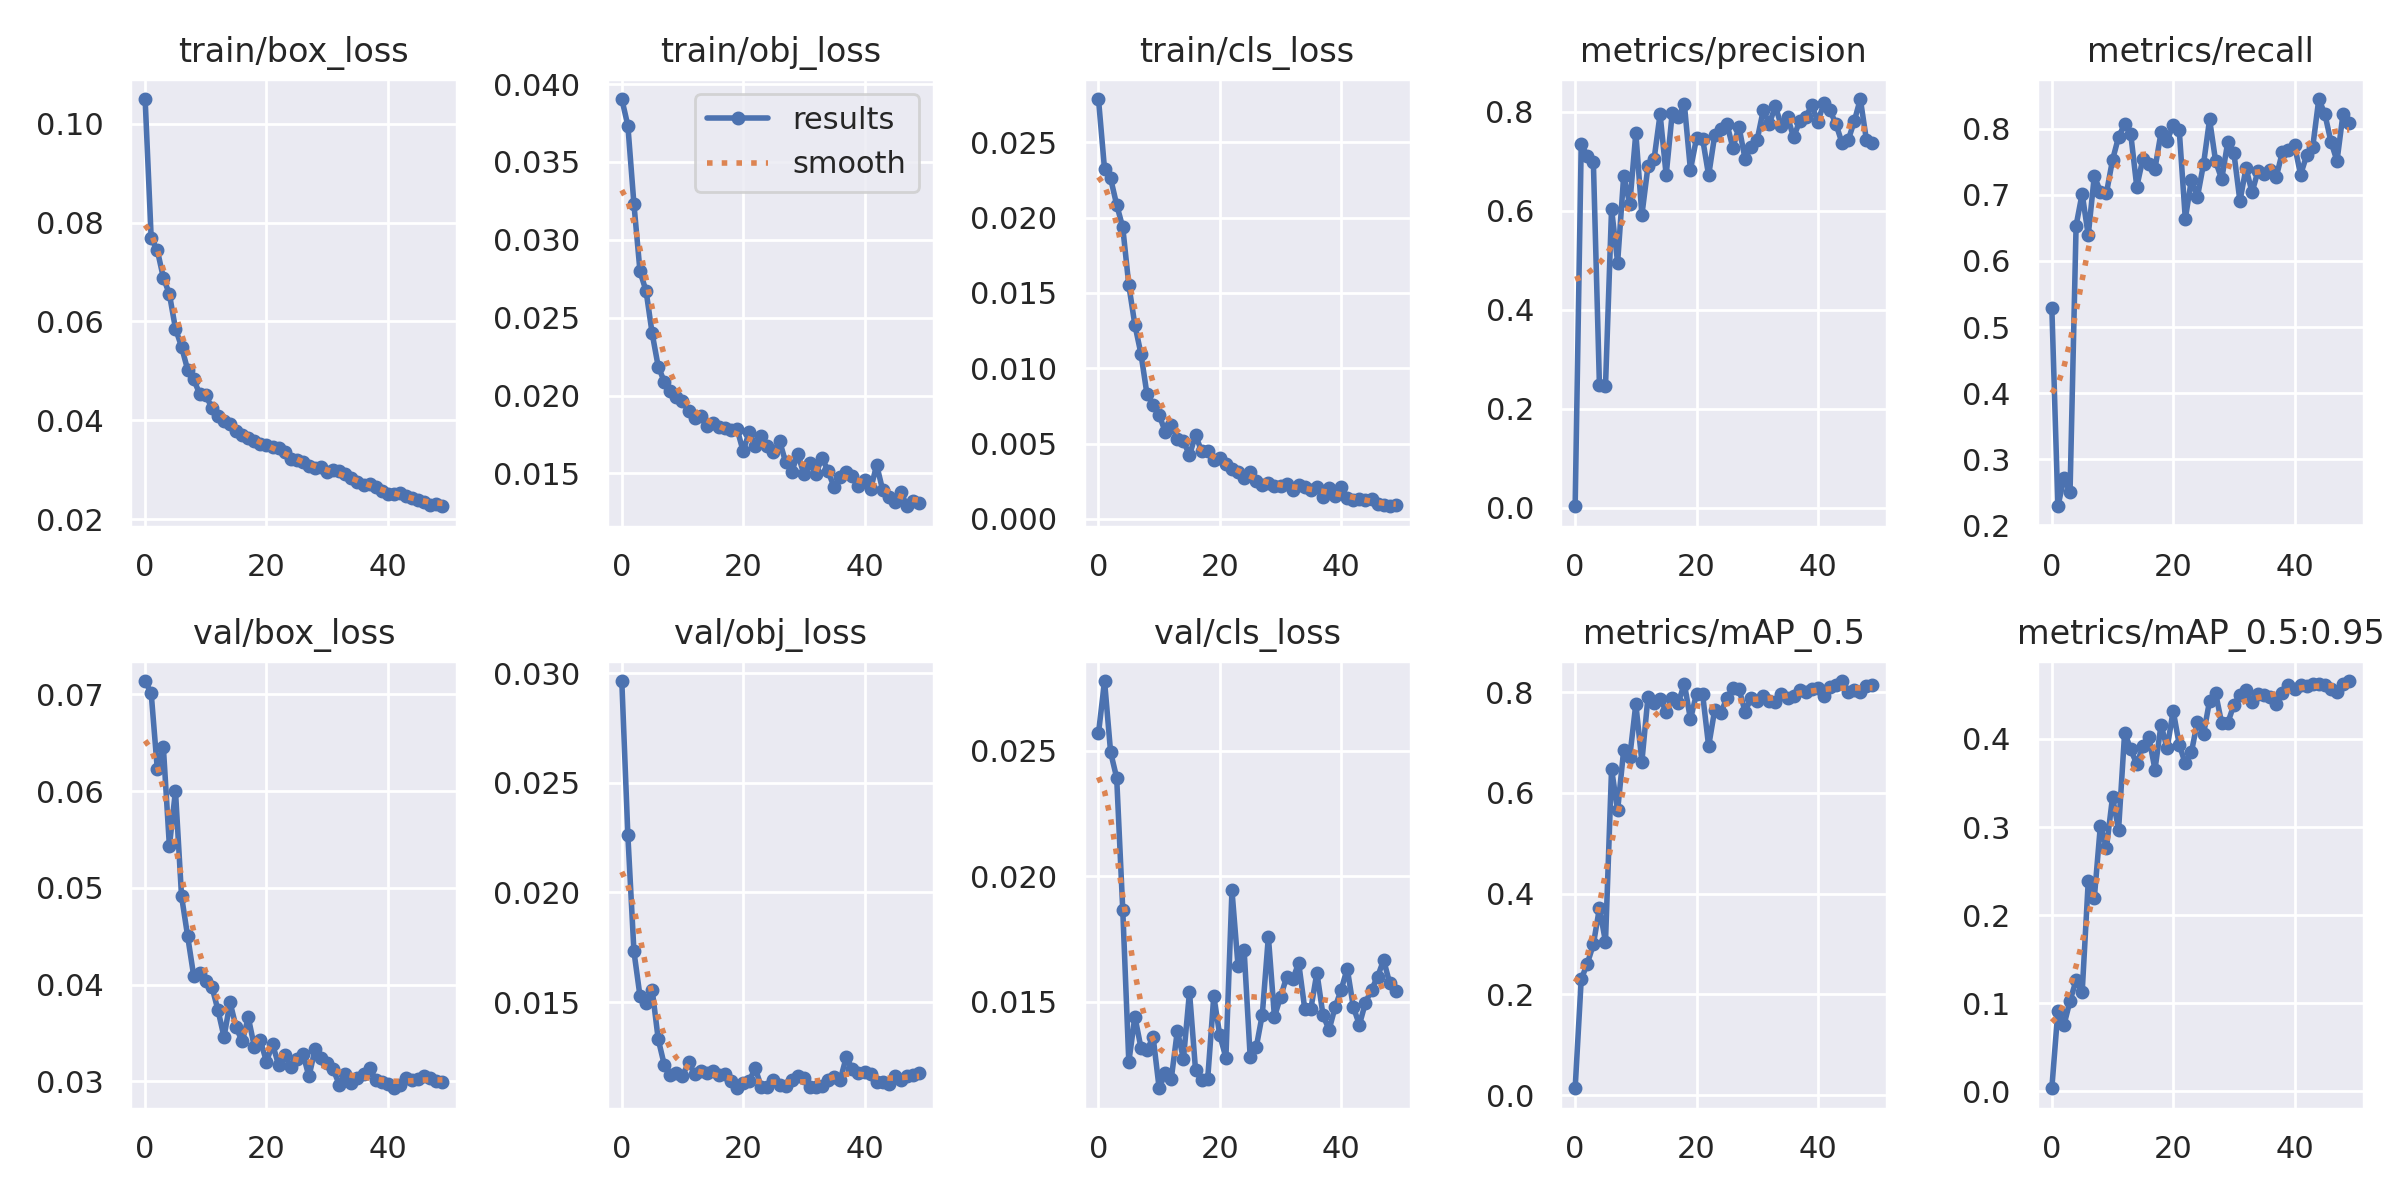

In [8]:
from IPython.display import Image
Image('/content/yolov5/runs/train/helmet_safecity/results.png')

In [9]:
!python detect.py \
  --weights /content/yolov5/runs/train/helmet_safecity/weights/best.pt \
  --img 640 \
  --conf 0.5 \
  --source /content/helmet_dataset/test/images \
  --device 0

detect: weights=['/content/yolov5/runs/train/helmet_safecity/weights/best.pt'], source=/content/helmet_dataset/test/images, data=data/coco128.yaml, imgsz=[640, 640], conf_thres=0.5, iou_thres=0.45, max_det=1000, device=0, view_img=False, save_txt=False, save_format=0, save_csv=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=exp, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5 🚀 v7.0-463-g88af13e3 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)

Fusing layers... 
Model summary: 157 layers, 7015519 parameters, 0 gradients, 15.8 GFLOPs
image 1/78 /content/helmet_dataset/test/images/BikesHelmets104_png.rf.79d42a3fd6ad64f9a17e166522c30fd4.jpg: 448x640 2 With Helmets, 34.7ms
image 2/78 /content/helmet_dataset/test/images/BikesHelmets110_png.rf.07f8deb9586456b64882fc4d0481121c.jpg: 448x640 4 Without Helm

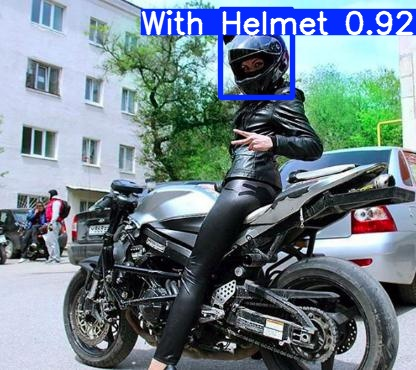

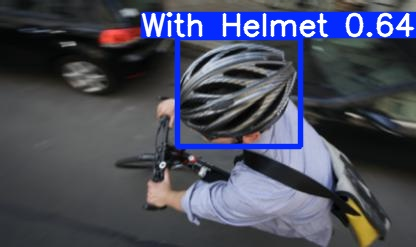

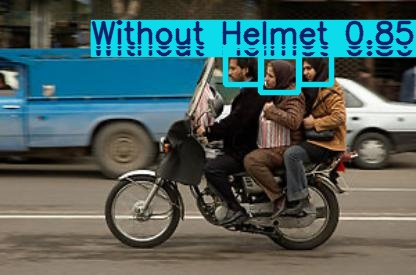

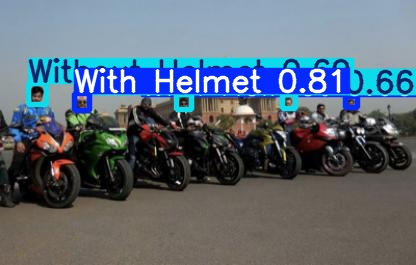

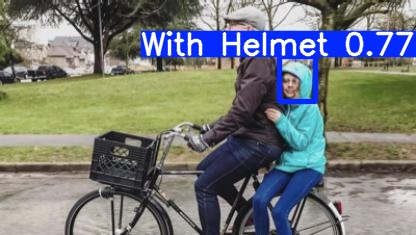

In [10]:
import glob
from IPython.display import Image, display

# Show first 5 detected images
images = glob.glob('/content/yolov5/runs/detect/exp/*.jpg')[:5]
for img in images:
    display(Image(img))

In [11]:
import shutil
from google.colab import files

shutil.make_archive('detection_results', 'zip', '/content/yolov5/runs/detect/exp')
files.download('detection_results.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [1]:
import os
os.chdir('/content/yolov5')
print("✅ Ready!")

FileNotFoundError: [Errno 2] No such file or directory: '/content/yolov5'

In [2]:
import os, yaml

# Step 1 - clone yolov5
os.chdir('/content')
os.system('git clone https://github.com/ultralytics/yolov5 -q')
os.system('pip install -r /content/yolov5/requirements.txt -q')
print("✅ YOLOv5 ready!")

# Step 2 - recreate yaml
data = {
    'train': '/content/helmet_dataset/train/images',
    'val': '/content/helmet_dataset/valid/images',
    'test': '/content/helmet_dataset/test/images',
    'nc': 2,
    'names': ['With Helmet', 'Without Helmet']
}
with open('/content/yolov5/helmet_data.yaml', 'w') as f:
    yaml.dump(data, f)
print("✅ Yaml ready!")

✅ YOLOv5 ready!
✅ Yaml ready!


In [3]:
from google.colab import files
uploaded = files.upload()
print("✅ Model uploaded!")

Saving best.pt to best.pt
✅ Model uploaded!


In [4]:
import shutil
shutil.copy('/content/best.pt', '/content/yolov5/best.pt')
print("✅ Model in place!")

✅ Model in place!


In [5]:
from google.colab import files
uploaded = files.upload()
print("✅ Video uploaded!")

Saving HOW TRIPLE RIDING VIOLATION _ Caught By CCTV Cam _ Tirupati Traffic Police.mp4 to HOW TRIPLE RIDING VIOLATION _ Caught By CCTV Cam _ Tirupati Traffic Police.mp4
✅ Video uploaded!


In [6]:
import os
os.chdir('/content/yolov5')

!python detect.py \
  --weights /content/yolov5/best.pt \
  --img 640 \
  --conf 0.5 \
  --source "/content/HOW TRIPLE RIDING VIOLATION _ Caught By CCTV Cam _ Tirupati Traffic Police.mp4" \
  --device 0 \
  --name traffic_demo
###```

#It will process frame by frame — you'll see output like:
#```
#video 1/1 frame 1/450 ...
#video 1/1 frame 2/450 ...

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
detect: weights=['/content/yolov5/best.pt'], source=/content/HOW TRIPLE RIDING VIOLATION _ Caught By CCTV Cam _ Tirupati Traffic Police.mp4, data=data/coco128.yaml, imgsz=[640, 640], conf_thres=0.5, iou_thres=0.45, max_det=1000, device=0, view_img=False, save_txt=False, save_format=0, save_csv=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=traffic_demo, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5 🚀 v7.0-463-g88af13e3 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)

Fusing layers... 
Mode

In [7]:
from google.colab import files
files.download('/content/yolov5/runs/detect/traffic_demo/HOW TRIPLE RIDING VIOLATION _ Caught By CCTV Cam _ Tirupati Traffic Police.mp4')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>